## Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from xgboost import XGBClassifier

In [2]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## 1. Load Data

In [4]:
df = pd.read_csv("Country-data.csv")
print("Shape:", df.shape)
print(df.head())
 
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
 
X = df[features]

Shape: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


## 2. Scale features

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Finding opTimal K

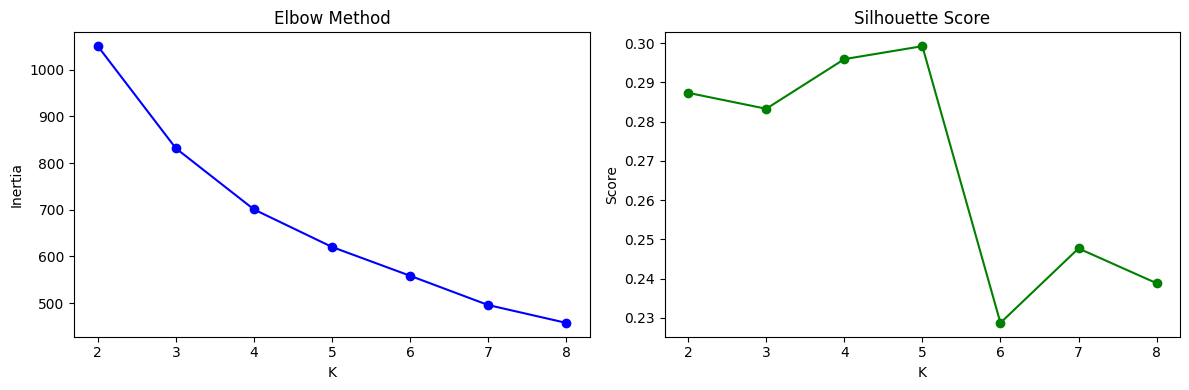

Best K by silhouette: 5


In [7]:
inertia, sil_scores = [], []
K_range = range(2, 9)
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
 
axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
 
plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150)
plt.show()
print("Best K by silhouette:", K_range[np.argmax(sil_scores)])

## 4. K-means clusttering

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
 
# Auto-label clusters by GDP
cluster_gdp = df.groupby('cluster')['gdpp'].mean().sort_values()
label_map = {cluster_gdp.index[0]: 'Underdeveloped',
             cluster_gdp.index[1]: 'Developing',
             cluster_gdp.index[2]: 'Developed'}
df['cluster_label'] = df['cluster'].map(label_map)
 
print("\nCluster sizes:")
print(df['cluster_label'].value_counts())
 
print("\nCluster means:")
print(df.groupby('cluster_label')[features].mean().round(2))


Cluster sizes:
cluster_label
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64

Cluster means:
                child_mort  exports  health  imports    income  inflation  \
cluster_label                                                               
Developed             5.00    58.74    8.81    51.49  45672.22       2.67   
Developing           21.93    40.24    6.20    47.47  12305.60       7.60   
Underdeveloped       92.96    29.15    6.39    42.32   3942.40      12.02   

                life_expec  total_fer      gdpp  
cluster_label                                    
Developed            80.13       1.75  42494.44  
Developing           72.81       2.31   6486.45  
Underdeveloped       59.19       5.01   1922.38  


## 5. DBSCAN (outlier detection)

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_label'] = dbscan.fit_predict(X_scaled)
n_noise = (df['dbscan_label'] == -1).sum()
print(f"\nDBSCAN — clusters: {df['dbscan_label'].nunique() - 1}, noise points: {n_noise}")


DBSCAN — clusters: 1, noise points: 30


## 6. Classification (Random forest)


Random Forest — CV Accuracy: 0.9576 ± 0.0454

Random Forest Classification Report:
                precision    recall  f1-score   support

     Developed       0.88      1.00      0.93         7
    Developing       0.94      0.94      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.94      0.95      0.94        34
  weighted avg       0.94      0.94      0.94        34



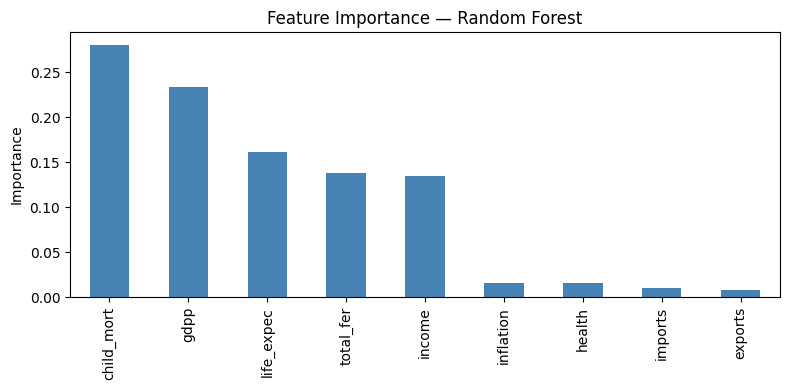

In [11]:
y = df['cluster_label']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
 
rf_cv = cross_val_score(rf, X_scaled, y, cv=5)
print(f"\nRandom Forest — CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf.predict(X_test)))
 
# Feature importance
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
fi.plot(kind='bar', color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 7. Classification (XGboost)

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)
 
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
 
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_tr, y_tr)
 
xgb_cv = cross_val_score(xgb, X_scaled, y_enc, cv=5)
print(f"\nXGBoost — CV Accuracy: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_te, xgb.predict(X_te), target_names=le.classes_))


XGBoost — CV Accuracy: 0.9579 ± 0.0240

XGBoost Classification Report:
                precision    recall  f1-score   support

     Developed       0.88      1.00      0.93         7
    Developing       0.94      0.94      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.94      0.95      0.94        34
  weighted avg       0.94      0.94      0.94        34



## 8. Confusion Matrix Plot

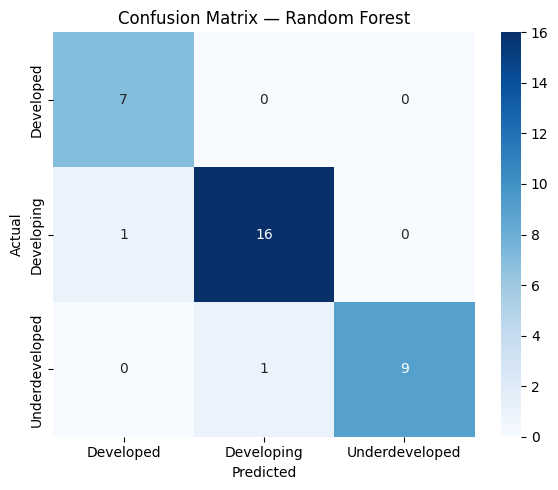

In [13]:
cm = confusion_matrix(y_test, rf.predict(X_test), labels=['Developed', 'Developing', 'Underdeveloped'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Developed', 'Developing', 'Underdeveloped'],
            yticklabels=['Developed', 'Developing', 'Underdeveloped'])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 9. SCATTER PLOT ( GDP VS Child mortality)

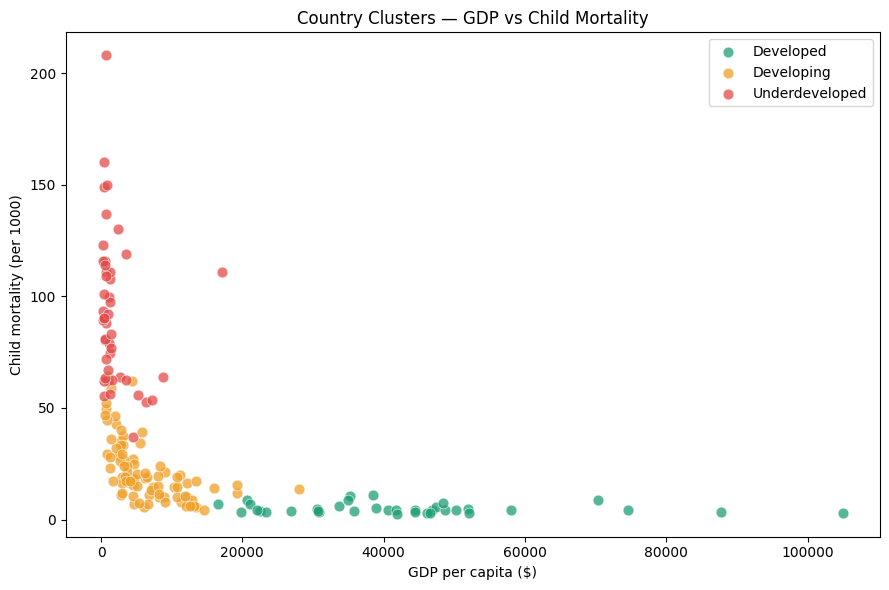

In [14]:
colors = {'Developed': '#1D9E75', 'Developing': '#EF9F27', 'Underdeveloped': '#E24B4A'}
plt.figure(figsize=(9, 6))
for label, grp in df.groupby('cluster_label'):
    plt.scatter(grp['gdpp'], grp['child_mort'],
                c=colors[label], label=label, alpha=0.75, edgecolors='white', linewidths=0.5, s=60)
plt.xlabel("GDP per capita ($)")
plt.ylabel("Child mortality (per 1000)")
plt.title("Country Clusters — GDP vs Child Mortality")
plt.legend()
plt.tight_layout()
plt.savefig("scatter_clusters.png", dpi=150)
plt.show()

## 10. Saving results

In [15]:
df[['country', 'cluster_label', 'gdpp', 'child_mort', 'life_expec', 'income']]\
  .sort_values('cluster_label')\
  .to_csv("country_results.csv", index=False)
print("\nResults saved to country_results.csv")
print("Done.")


Results saved to country_results.csv
Done.
